In [25]:
from jax import numpy as jnp
import numpy as np

import unxt

from fdm_edl.op.cartesian.fd import _uniform_grad
from fdm_edl.api.bc import Stern, ConstP
from fdm_edl.api import ElectricalDoubleLayer

from matplotlib import pyplot as plt

In [49]:
x_img = unxt.Quantity(0.9, "angstrom")
x_OHP = unxt.Quantity(4.5, "angstrom")

eps_s = 6.0
eps_gc = 78.4

n_grid = 500

In [50]:
solvent_type = "uniform"
edl_obj = ElectricalDoubleLayer(f"input_{solvent_type}.json")
debye_length = edl_obj.electrolyte.debye_length
x = (
    unxt.Quantity(
        jnp.linspace(0.0, debye_length.to("angstrom").value * 10.0, n_grid),
        unit="angstrom",
    )
    + x_OHP
)
all_phi = unxt.Quantity(jnp.linspace(-2.0, 2.0, 30), unit="V")

phi0_guess = None
sigma = []
for phi in all_phi:
    bcs = ()
    bcs += Stern(
        phi=phi,
        eps_gc=eps_gc,
        eps_s=eps_s,
        d_s=x_OHP - x_img,
    )([0])
    bcs += ConstP(unxt.Quantity(0.0, "V"))([-1])

    edl_obj.compute(x, bcs, phi0=phi0_guess)
    assert edl_obj.result is not None
    phi0_guess = edl_obj.result.phi
    sigma.append(edl_obj.result.sigma.to("uC/cm^2").value)

x = all_phi.to("V").value
y = jnp.asarray(sigma)
np.savetxt(
    f"{solvent_type}.txt", np.transpose([x, y]), header="phi (V)\tsigma (uC/cm^2)"
)

In [51]:
solvent_type = "booth"
edl_obj = ElectricalDoubleLayer(f"input_{solvent_type}.json")
debye_length = edl_obj.electrolyte.debye_length
x = (
    unxt.Quantity(
        jnp.linspace(0.0, debye_length.to("angstrom").value * 10.0, n_grid),
        unit="angstrom",
    )
    + x_OHP
)
all_phi = unxt.Quantity(jnp.linspace(-2.0, 2.0, 30), unit="V")

phi0_guess = None
sigma = []
for phi in all_phi:
    bcs = ()
    bcs += Stern(
        phi=phi,
        eps_gc=eps_gc,
        eps_s=eps_s,
        d_s=x_OHP - x_img,
    )([0])
    bcs += ConstP(unxt.Quantity(0.0, "V"))([-1])

    edl_obj.compute(x, bcs, phi0=phi0_guess)
    assert edl_obj.result is not None
    phi0_guess = edl_obj.result.phi
    sigma.append(edl_obj.result.sigma.to("uC/cm^2").value)

x = all_phi.to("V").value
y = jnp.asarray(sigma)
np.savetxt(
    f"{solvent_type}.txt", np.transpose([x, y]), header="phi (V)\tsigma (uC/cm^2)"
)

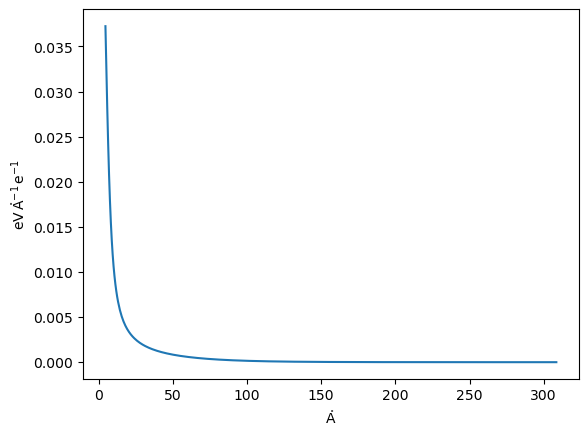

In [57]:
# plt.plot(edl_obj.result.coordinate, edl_obj.result.phi)
# plt.plot([x_img.value, edl_obj.result.coordinate[0].value], [phi.value, edl_obj.result.phi[0].value])
plt.plot(edl_obj.result.coordinate, edl_obj.result.efield)

plt.show()

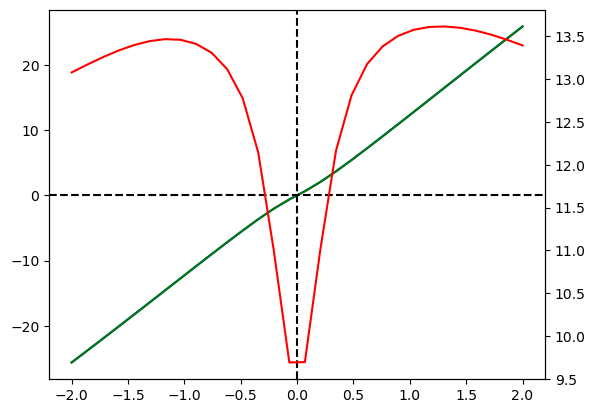

In [55]:
fig, ax_l = plt.subplots()

data = np.loadtxt("booth.txt")
x = data[:, 0]
y = data[:, 1]
# charging curve
ax_l.plot(x, y, color="blue")

data = np.loadtxt("uniform.txt")
x = data[:, 0]
y = data[:, 1]
# charging curve
ax_l.plot(x, y, color="green")
ax_l.axhline(0.0, color="black", linestyle="--")

ax_r = ax_l.twinx()
ax_r.plot(x, _uniform_grad(x, jnp.asarray(y), 4, 3), color="red")

ax_l.axvline(0.0, color="black", linestyle="--")

plt.show()